# 🔬 NephroScan AI v2 — 4-Class Kidney Classifier

**Classes:** Normal · Cyst · Stone · Tumour

**Dataset:** 12,446 CT images — Normal=5,077 · Cyst=3,709 · Stone=1,377 · Tumour=2,283

**Model:** EfficientNet-B4 (pretrained ImageNet) + custom 4-class head

Run cells top to bottom. Training takes ~2 hours on Apple MPS.

## Cell 1 — Imports & Setup

In [1]:
import os, sys, cv2, hashlib, torch, timm, time
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Paths ──────────────────────────────────────────────────────────────────
PROJECT_ROOT = '/Users/devaguru/Kidney Stone CNN/nephroscan-v2'
SRC_ROOT     = '/Users/devaguru/Kidney Stone CNN/kidney-stone-cnn/data/external/kidney_kaggle'
DATA_ROOT    = f'{PROJECT_ROOT}/data/processed'
CHECKPOINT   = f'{PROJECT_ROOT}/checkpoints/best_model_v2.pth'

os.makedirs(f'{PROJECT_ROOT}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_ROOT}/reports',     exist_ok=True)
os.chdir(PROJECT_ROOT)

# ── Device ─────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# ── Config ─────────────────────────────────────────────────────────────────
CLASS_MAP    = {'Normal':'normal','Cyst':'cyst','Stone':'stone','Tumor':'tumour'}
CLASS_NAMES  = ['normal','cyst','stone','tumour']
CLASS_TO_IDX = {c:i for i,c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = 4
IMG_SIZE     = 224
BATCH_SIZE   = 8
EPOCHS       = 10
LR_HEAD      = 1e-3
LR_BACKBONE  = 1e-4
UNFREEZE_EPOCH = 4

print(f'Device:      {device}')
print(f'Project:     {PROJECT_ROOT}')
print(f'Source data: {SRC_ROOT}')
print(f'Classes:     {CLASS_NAMES}')
print('Ready ✅')

Device:      mps
Project:     /Users/devaguru/Kidney Stone CNN/nephroscan-v2
Source data: /Users/devaguru/Kidney Stone CNN/kidney-stone-cnn/data/external/kidney_kaggle
Classes:     ['normal', 'cyst', 'stone', 'tumour']
Ready ✅


## Cell 2 — Data Preprocessing & Split

In [2]:
def stable_hash(filename):
    h = int(hashlib.md5(filename.encode()).hexdigest(), 16)
    return (h % 10000) / 10000.0

def get_split(filename):
    v = stable_hash(filename)
    return 'train' if v < 0.70 else ('val' if v < 0.85 else 'test')

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8,8)).apply(l)
    return cv2.cvtColor(cv2.merge([l,a,b]), cv2.COLOR_LAB2BGR)

# Create output folders
for split in ['train','val','test']:
    for cls in CLASS_NAMES:
        os.makedirs(f'{DATA_ROOT}/{split}/{cls}', exist_ok=True)

stats = {s:{c:0 for c in CLASS_NAMES} for s in ['train','val','test']}
already_done = True

# Check if already preprocessed
for split in ['train','val','test']:
    for cls in CLASS_NAMES:
        if len(list(Path(f'{DATA_ROOT}/{split}/{cls}').glob('*.jpg'))) == 0:
            already_done = False
            break

if already_done:
    print('Data already preprocessed — skipping. Counting images...')
    for split in ['train','val','test']:
        for cls in CLASS_NAMES:
            stats[split][cls] = len(list(Path(f'{DATA_ROOT}/{split}/{cls}').glob('*.jpg')))
else:
    print('Preprocessing images (first time — takes ~5 minutes)...')
    for src_cls, dst_cls in CLASS_MAP.items():
        src_dir = Path(SRC_ROOT) / src_cls
        images  = list(src_dir.glob('*.jpg')) + list(src_dir.glob('*.png'))
        print(f'  {src_cls}: {len(images)} images')
        for img_path in tqdm(images, desc=src_cls):
            split = get_split(img_path.name)
            dst   = Path(DATA_ROOT) / split / dst_cls / img_path.name
            if dst.exists(): continue
            img = cv2.imread(str(img_path))
            if img is None: continue
            img = cv2.resize(img, (IMG_SIZE,IMG_SIZE), interpolation=cv2.INTER_LANCZOS4)
            img = apply_clahe(img)
            cv2.imwrite(str(dst), img)
            stats[split][dst_cls] += 1

print('\n=== DATASET SPLIT ===')
for split in ['train','val','test']:
    total = sum(stats[split].values())
    print(f'[{split}] total={total}')
    for cls in CLASS_NAMES:
        print(f'  {cls:8s}: {stats[split][cls]}')
print('\nDone ✅')

Preprocessing images (first time — takes ~5 minutes)...
  Normal: 5077 images


Normal:   0%|          | 0/5077 [00:00<?, ?it/s]

  Cyst: 3709 images


Cyst:   0%|          | 0/3709 [00:00<?, ?it/s]

  Stone: 1377 images


Stone:   0%|          | 0/1377 [00:00<?, ?it/s]

  Tumor: 2283 images


Tumor:   0%|          | 0/2283 [00:00<?, ?it/s]


=== DATASET SPLIT ===
[train] total=8650
  normal  : 3608
  cyst    : 2562
  stone   : 947
  tumour  : 1533
[val] total=1841
  normal  : 719
  cyst    : 542
  stone   : 222
  tumour  : 358
[test] total=1955
  normal  : 750
  cyst    : 605
  stone   : 208
  tumour  : 392

Done ✅


## Cell 3 — Verify Class Distribution

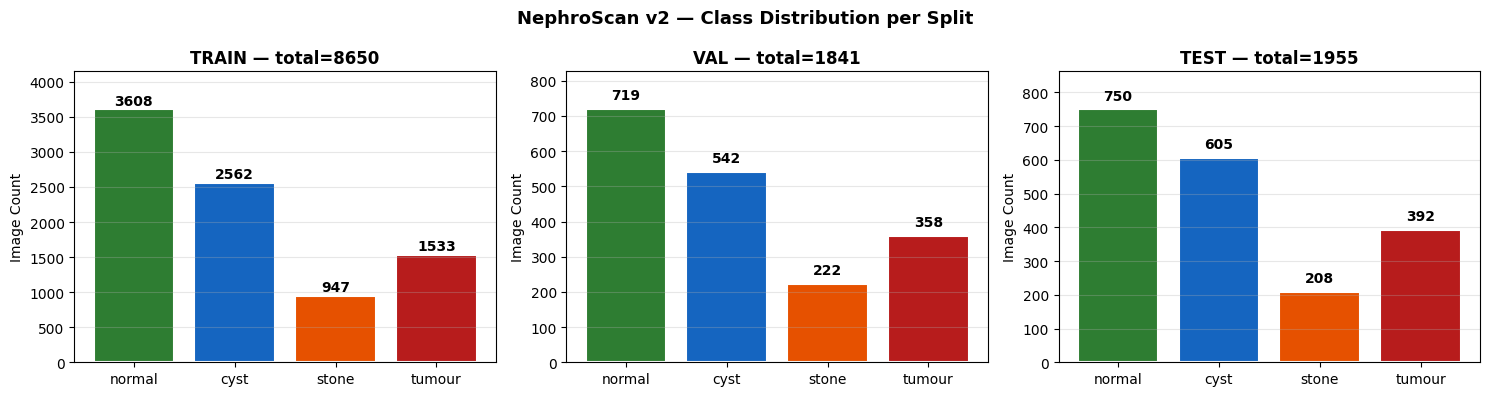

Chart saved to reports/class_distribution_v2.png


In [3]:
COLORS = {'normal':'#2E7D32','cyst':'#1565C0','stone':'#E65100','tumour':'#B71C1C'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('NephroScan v2 — Class Distribution per Split', fontsize=13, fontweight='bold')

for ax, split in zip(axes, ['train','val','test']):
    counts = [len(list(Path(f'{DATA_ROOT}/{split}/{cls}').glob('*.jpg'))) for cls in CLASS_NAMES]
    bars   = ax.bar(CLASS_NAMES, counts, color=[COLORS[c] for c in CLASS_NAMES], edgecolor='white', linewidth=1.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20, str(count),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(f'{split.upper()} — total={sum(counts)}', fontweight='bold')
    ax.set_ylabel('Image Count')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(counts)*1.15)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/reports/class_distribution_v2.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to reports/class_distribution_v2.png')

## Cell 4 — Model, Dataset & Transforms

In [4]:
# ── Transforms ─────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def get_train_transforms(size=224):
    return A.Compose([
        A.RandomRotate90(p=0.5),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=20, p=0.6),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.GaussNoise(var_limit=(10,50), p=0.3),
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

def get_val_transforms(size=224):
    return A.Compose([
        A.Normalize(mean=MEAN, std=STD),
        ToTensorV2(),
    ])

# ── Dataset ─────────────────────────────────────────────────────────────────
class KidneyDatasetV2(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []
        for cls, label in CLASS_TO_IDX.items():
            for p in (Path(root_dir)/cls).glob('*'):
                if p.suffix.lower() in ['.jpg','.jpeg','.png']:
                    self.samples.append((str(p), label))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        if self.transform: img = self.transform(image=img)['image']
        return img, label

def get_weighted_sampler(dataset):
    labels  = [s[1] for s in dataset.samples]
    counts  = Counter(labels)
    weights = [1.0/counts[l] for l in labels]
    return WeightedRandomSampler(weights, len(weights), replacement=True)

# ── Model ───────────────────────────────────────────────────────────────────
class KidneyClassifierV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b4', pretrained=True, num_classes=0, global_pool='avg')
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, NUM_CLASSES),
        )
    def forward(self, x): return self.classifier(self.backbone(x))
    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True

# ── Focal Loss ──────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        loss = ((1 - torch.exp(-ce)) ** self.gamma) * ce
        return loss.mean()

# ── Build datasets & loaders ────────────────────────────────────────────────
train_ds = KidneyDatasetV2(f'{DATA_ROOT}/train', get_train_transforms())
val_ds   = KidneyDatasetV2(f'{DATA_ROOT}/val',   get_val_transforms())
test_ds  = KidneyDatasetV2(f'{DATA_ROOT}/test',  get_val_transforms())

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=get_weighted_sampler(train_ds), num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ── Init model ──────────────────────────────────────────────────────────────
model     = KidneyClassifierV2().to(device)
criterion = FocalLoss(gamma=2.0)
model.freeze_backbone()
optimizer = optim.AdamW(model.classifier.parameters(), lr=LR_HEAD)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model:       EfficientNet-B4 + 4-class head')
print(f'Parameters:  {total_params:,}')
print(f'Train:       {len(train_ds)} images')
print(f'Val:         {len(val_ds)} images')
print(f'Test:        {len(test_ds)} images')
print(f'Device:      {device}')
print('Ready to train ✅')

Model:       EfficientNet-B4 + 4-class head
Parameters:  18,473,292
Train:       8650 images
Val:         1841 images
Test:        1955 images
Device:      mps
Ready to train ✅


## Cell 5 — Training Loop

In [6]:
history = {'epoch':[],'train_loss':[],'val_acc':[],'val_auc':[],'tumour_recall':[]}
best_val_acc = 0.0

print(f'Training for {EPOCHS} epochs on {device}')
print(f'Backbone unfreezes at epoch {UNFREEZE_EPOCH}')
print('='*65)

for epoch in range(1, EPOCHS+1):
    epoch_start = time.time()

    # Unfreeze backbone at epoch 4
    if epoch == UNFREEZE_EPOCH:
        model.unfreeze_backbone()
        optimizer = optim.AdamW([
            {'params': model.backbone.parameters(),   'lr': LR_BACKBONE},
            {'params': model.classifier.parameters(), 'lr': LR_HEAD},
        ], weight_decay=1e-4)
        print(f'  >> Epoch {epoch}: backbone UNFROZEN — fine-tuning entire model')

    # ── Training pass ──────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    train_bar  = tqdm(train_dl, desc=f'Epoch {epoch:02d} [train]', leave=False)
    for imgs, labels in train_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_bar.set_postfix(loss=f'{loss.item():.4f}')
    train_loss /= len(train_dl)

    # ── Validation pass ────────────────────────────────────────────────────
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_dl, desc=f'Epoch {epoch:02d} [val]  ', leave=False):
            logits = model(imgs.to(device))
            probs  = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    val_acc = (all_preds == all_labels).mean()
    auc     = roc_auc_score(label_binarize(all_labels, classes=[0,1,2,3]),
                            all_probs, multi_class='ovr', average='macro')

    # Per-class recall
    report      = classification_report(all_labels, all_preds,
                      target_names=CLASS_NAMES, output_dict=True)
    tumour_rec  = report['tumour']['recall']
    stone_rec   = report['stone']['recall']
    elapsed     = time.time() - epoch_start

    print(f'Epoch {epoch:02d}/{EPOCHS} | loss={train_loss:.4f} | acc={val_acc:.4f} | '
          f'auc={auc:.4f} | tumour_recall={tumour_rec:.4f} | stone_recall={stone_rec:.4f} | '
          f'{elapsed:.0f}s')

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(auc)
    history['tumour_recall'].append(tumour_rec)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT)
        print(f'  ✅ Best model saved → {CHECKPOINT}')

print('='*65)
print(f'Training complete. Best val accuracy: {best_val_acc:.4f}')

Training for 10 epochs on mps
Backbone unfreezes at epoch 4


Epoch 01 [train]:   0%|          | 0/1082 [00:00<?, ?it/s]

Epoch 01 [val]  :   0%|          | 0/231 [00:00<?, ?it/s]

Epoch 01/10 | loss=0.5675 | acc=0.7143 | auc=0.9041 | tumour_recall=0.6704 | stone_recall=0.7568 | 156s
  ✅ Best model saved → /Users/devaguru/Kidney Stone CNN/nephroscan-v2/checkpoints/best_model_v2.pth


Epoch 02 [train]:   0%|          | 0/1082 [00:00<?, ?it/s]

...

Epoch 06 [train]:   0%|          | 0/1082 [00:00<?, ?it/s]

Epoch 06 [val]  :   0%|          | 0/231 [00:00<?, ?it/s]

Epoch 06/10 | loss=0.1667 | acc=0.9723 | auc=0.9986 | tumour_recall=0.9274 | stone_recall=0.9459 | 763s
  ✅ Best model saved → /Users/devaguru/Kidney Stone CNN/nephroscan-v2/checkpoints/best_model_v2.pth


Epoch 07 [train]:   0%|          | 0/1082 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Cell 6 — Training Curves

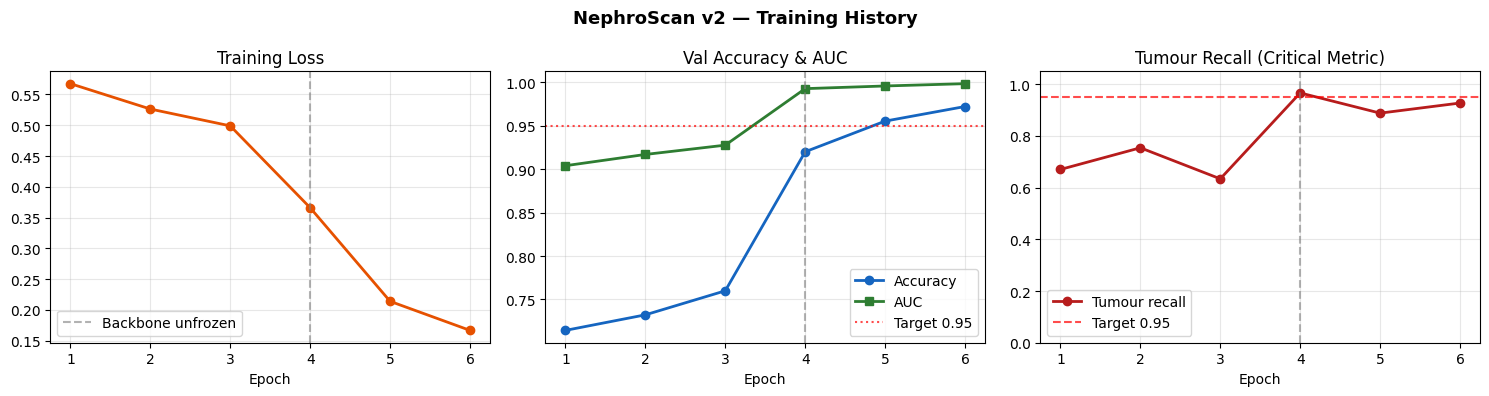

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('NephroScan v2 — Training History', fontsize=13, fontweight='bold')
epochs = history['epoch']

axes[0].plot(epochs, history['train_loss'], 'o-', color='#E65100', lw=2)
axes[0].axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6, label='Backbone unfrozen')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_acc'],  'o-', color='#1565C0', lw=2, label='Accuracy')
axes[1].plot(epochs, history['val_auc'],  's-', color='#2E7D32', lw=2, label='AUC')
axes[1].axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6)
axes[1].axhline(0.95, color='red', linestyle=':', alpha=0.7, label='Target 0.95')
axes[1].set_title('Val Accuracy & AUC'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history['tumour_recall'], 'o-', color='#B71C1C', lw=2, label='Tumour recall')
axes[2].axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Target 0.95')
axes[2].axvline(UNFREEZE_EPOCH, color='gray', linestyle='--', alpha=0.6)
axes[2].set_title('Tumour Recall (Critical Metric)'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(alpha=0.3); axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/reports/training_curves_v2.png', dpi=120, bbox_inches='tight')
plt.show()

## Cell 7 — Test Set Evaluation

In [9]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print(f'Loaded best model from: {CHECKPOINT}')

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in tqdm(test_dl, desc='Evaluating test set'):
        logits = model(imgs.to(device))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

accuracy = (all_preds == all_labels).mean()
auc      = roc_auc_score(label_binarize(all_labels, classes=[0,1,2,3]),
                         all_probs, multi_class='ovr', average='macro')

print('='*60)
print('  TEST SET RESULTS — NephroScan v2')
print('='*60)
print(f'  Overall Accuracy:  {accuracy:.4f}')
print(f'  Macro AUC-ROC:     {auc:.4f}')
print('-'*60)
print(classification_report(all_labels, all_preds,
      target_names=CLASS_NAMES, digits=4))

# Highlight tumour recall specifically
report = classification_report(all_labels, all_preds,
             target_names=CLASS_NAMES, output_dict=True)
tumour_recall = report['tumour']['recall']
stone_recall  = report['stone']['recall']
status_t = '✅' if tumour_recall >= 0.93 else '⚠️  Below target'
status_s = '✅' if stone_recall  >= 0.91 else '⚠️  Below target'
print(f'  Tumour recall: {tumour_recall:.4f}  {status_t}')
print(f'  Stone recall:  {stone_recall:.4f}  {status_s}')
print('='*60)

Loaded best model from: /Users/devaguru/Kidney Stone CNN/nephroscan-v2/checkpoints/best_model_v2.pth


Evaluating test set:   0%|          | 0/245 [00:00<?, ?it/s]

  TEST SET RESULTS — NephroScan v2
  Overall Accuracy:  0.9698
  Macro AUC-ROC:     0.9984
------------------------------------------------------------
              precision    recall  f1-score   support

      normal     0.9614    0.9960    0.9784       750
        cyst     0.9801    0.9769    0.9785       605
       stone     0.9314    0.9135    0.9223       208
      tumour     0.9919    0.9388    0.9646       392

    accuracy                         0.9698      1955
   macro avg     0.9662    0.9563    0.9610      1955
weighted avg     0.9701    0.9698    0.9697      1955

  Tumour recall: 0.9388  ✅
  Stone recall:  0.9135  ✅


## Cell 8 — Confusion Matrix & Per-Class Charts

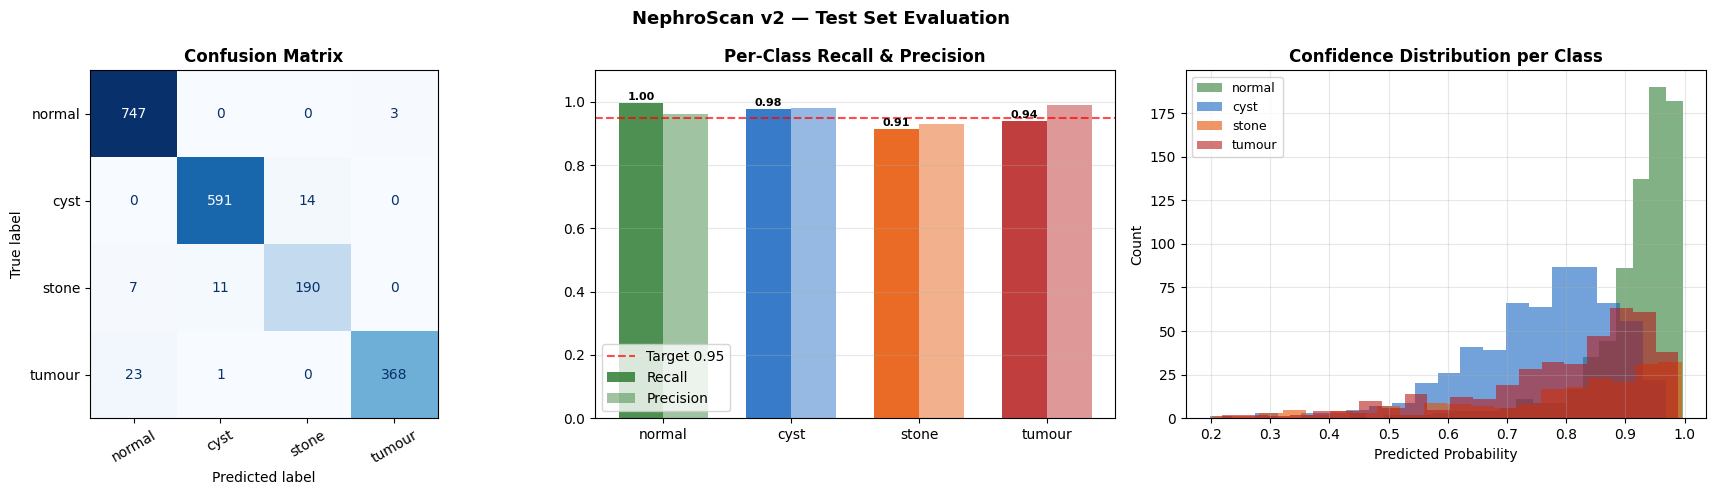

Saved to reports/evaluation_v2.png


In [10]:
fig = plt.figure(figsize=(18, 5))
fig.suptitle('NephroScan v2 — Test Set Evaluation', fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ── Confusion Matrix ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
cm  = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix', fontweight='bold')
plt.setp(ax1.get_xticklabels(), rotation=30)

# ── Per-Class Recall ──────────────────────────────────────────────────────
ax2   = fig.add_subplot(gs[1])
recs  = [report[c]['recall']    for c in CLASS_NAMES]
precs = [report[c]['precision'] for c in CLASS_NAMES]
x     = np.arange(len(CLASS_NAMES))
w     = 0.35
b1 = ax2.bar(x-w/2, recs,  w, label='Recall',    color=[COLORS[c] for c in CLASS_NAMES], alpha=0.85)
b2 = ax2.bar(x+w/2, precs, w, label='Precision', color=[COLORS[c] for c in CLASS_NAMES], alpha=0.45)
ax2.axhline(0.95, color='red', linestyle='--', alpha=0.7, label='Target 0.95')
ax2.set_xticks(x); ax2.set_xticklabels(CLASS_NAMES)
ax2.set_ylim(0, 1.1); ax2.set_title('Per-Class Recall & Precision', fontweight='bold')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
for bar in b1:
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{bar.get_height():.2f}', ha='center', fontsize=8, fontweight='bold')

# ── Confidence Distribution per Class ─────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
for i, cls in enumerate(CLASS_NAMES):
    mask = all_labels == i
    ax3.hist(all_probs[mask, i], bins=20, alpha=0.6,
             color=COLORS[cls], label=cls)
ax3.set_xlabel('Predicted Probability')
ax3.set_ylabel('Count')
ax3.set_title('Confidence Distribution per Class', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PROJECT_ROOT}/reports/evaluation_v2.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to reports/evaluation_v2.png')

## Cell 9 — Sample Predictions with Images

/var/folders/j6/pzqtnpsn3jg_xgp4jg2_w4bc0000gn/T/ipykernel_39486/2638277019.py:36: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/var/folders/j6/pzqtnpsn3jg_xgp4jg2_w4bc0000gn/T/ipykernel_39486/2638277019.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(f'{PROJECT_ROOT}/reports/sample_predictions_v2.png', dpi=100, bbox_inches='tight')
/Users/devaguru/Kidney Stone CNN/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


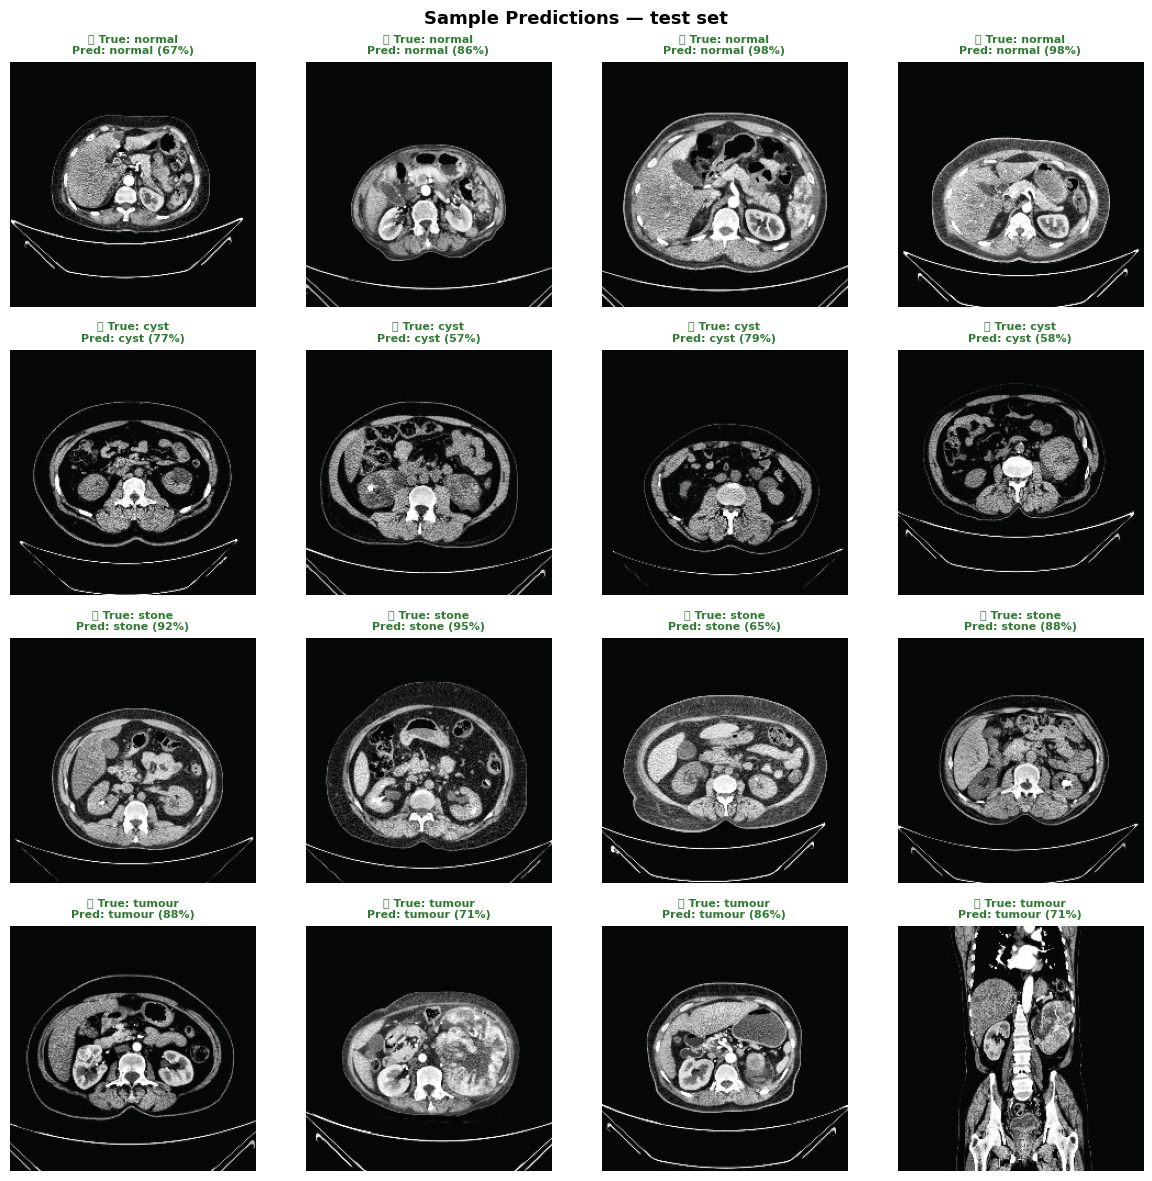

Saved to reports/sample_predictions_v2.png


In [11]:
CLINICAL_NOTES = {
    'normal': 'No abnormality. Routine follow-up.',
    'cyst':   'Cyst detected. Usually benign.',
    'stone':  'Stone detected. Urology referral.',
    'tumour': 'Renal mass. Urgent referral.',
}

def show_predictions(split='test', n_per_class=3):
    fig, axes = plt.subplots(NUM_CLASSES, n_per_class, figsize=(n_per_class*3, NUM_CLASSES*3))
    fig.suptitle(f'Sample Predictions — {split} set', fontsize=13, fontweight='bold')

    for row, cls in enumerate(CLASS_NAMES):
        cls_dir = Path(DATA_ROOT) / split / cls
        images  = list(cls_dir.glob('*.jpg'))[:n_per_class]
        for col, img_path in enumerate(images):
            ax = axes[row][col]
            img_bgr = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            tensor  = get_val_transforms()(image=img_rgb)['image'].unsqueeze(0).to(device)
            with torch.no_grad():
                probs = torch.softmax(model(tensor), dim=1)[0].cpu().numpy()
            pred_idx  = int(probs.argmax())
            pred_name = CLASS_NAMES[pred_idx]
            confidence= probs[pred_idx]
            correct   = pred_name == cls
            ax.imshow(img_rgb)
            color = '#2E7D32' if correct else '#B71C1C'
            icon  = '✅' if correct else '❌'
            ax.set_title(f'{icon} True: {cls}\nPred: {pred_name} ({confidence:.0%})',
                         fontsize=8, color=color, fontweight='bold')
            ax.axis('off')
            # Fill empty slots
        for col in range(len(images), n_per_class):
            axes[row][col].axis('off')

    plt.tight_layout()
    plt.savefig(f'{PROJECT_ROOT}/reports/sample_predictions_v2.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('Saved to reports/sample_predictions_v2.png')

show_predictions(split='test', n_per_class=4)

## Cell 10 — Quick Inference on Any Image

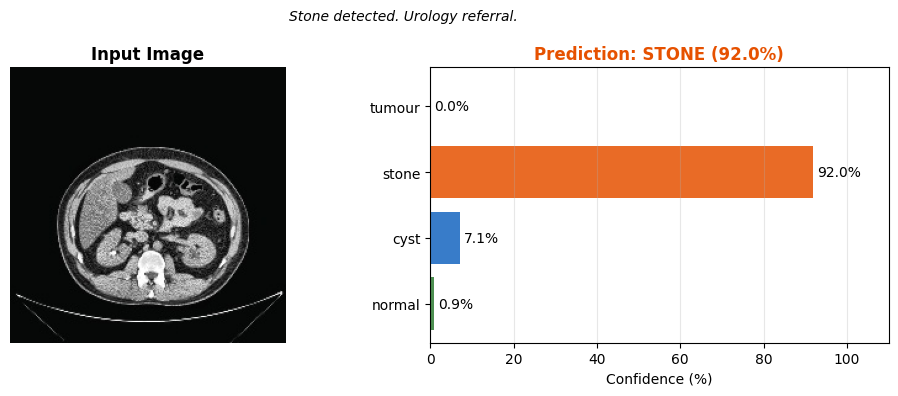

{'prediction': 'stone', 'confidence': 0.9195975065231323, 'probabilities': {'normal': 0.00947226770222187, 'cyst': 0.07058820873498917, 'stone': 0.9195975065231323, 'tumour': 0.00034209000295959413}, 'clinical_note': 'Stone detected. Urology referral.'}


In [12]:
def predict_image(image_path: str):
    """Run prediction on any image file."""
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    tensor = get_val_transforms()(image=img)['image'].unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0].cpu().numpy()
    pred_idx  = int(probs.argmax())
    pred_name = CLASS_NAMES[pred_idx]

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title(f'Input Image', fontweight='bold')
    axes[0].axis('off')
    bars = axes[1].barh(CLASS_NAMES, probs*100,
                        color=[COLORS[c] for c in CLASS_NAMES], alpha=0.85)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_xlim(0, 110)
    axes[1].set_title(f'Prediction: {pred_name.upper()} ({probs[pred_idx]:.1%})',
                      fontweight='bold', color=COLORS[pred_name])
    for bar, prob in zip(bars, probs):
        axes[1].text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                     f'{prob:.1%}', va='center', fontsize=10)
    axes[1].grid(axis='x', alpha=0.3)
    plt.suptitle(CLINICAL_NOTES[pred_name], fontsize=10,
                 color='red' if pred_name=='tumour' else 'black', style='italic')
    plt.tight_layout()
    plt.show()
    return {'prediction': pred_name, 'confidence': float(probs[pred_idx]),
            'probabilities': {CLASS_NAMES[i]: float(probs[i]) for i in range(4)},
            'clinical_note': CLINICAL_NOTES[pred_name]}

# ── Test on a stone image ──────────────────────────────────────────────────
test_images = list(Path(f'{DATA_ROOT}/test/stone').glob('*.jpg'))
if test_images:
    result = predict_image(str(test_images[0]))
    print(result)
else:
    print('No test images found — run Cell 2 first')